<a href="https://colab.research.google.com/github/StanStarishko/climate-impact-ml/blob/main/machine_learning_climate_impact.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  J1BB35 Machine Learning Assessment (Level 8)
*Scenario*

You have been hired by an organisation working in the environmental science sector specialising in the impact of climate change. They have hired you for two machine learning projects:


1.   Arctic Sea Ice
2.   Forest Fires

You have been tasked to create machine learning models that help with the prediction of the above. You will be working as part of a team and along side a data engineer - who has prepared much of the data to enable yourself to begin modelling and evaluating.

In addition, there are a series of theory questions for you to answer within this colab.

Finally, your submission will be this colab as a .ipynb file, which can be saved to your machine via "File > Download > Download .ipynb"

*Dataset Credits*
*   https://github.com/mwaskom/seaborn-data/blob/master/seaice.csv which is originally from
https://nsidc.org/sea-ice-today/sea-ice-tools
*   https://open-meteo.com/en/docs/historical-weather-api which is originally from https://www.ecmwf.int/
*   https://www.kaggle.com/datasets/phylake1337/fire-dataset
*   https://www.tensorflow.org/api_docs/python/tf/keras/datasets/cifar10/load_data






# Assessment Conditions
This evidence may be produced over the life of the unit, under loosely controlled conditions
(including access to reference materials). As the evidence is produced in loosely controlled
conditions it will be authenticated.

# Learning Outcomes

J1BB35 Machine Learning (2 SQA Credits):

[https://www.sqa.org.uk/files/hn/J1BB35.pdf](https://www.sqa.org.uk/files/hn/J1BB35.pdf)

# Theory Assessment

**1) Explain supervised learning and the difference between classification and regression predictive models**

Supervised learning is the branch of machine learning where the model learns from examples that come with the answers attached. Each training example is a pair of an input and a label, and the job of the training process is to find a function that maps inputs to labels well enough that it generalises to new examples it has not seen. The label is the supervision: it tells the model whether each prediction is right or wrong, and the loss function measures the gap between prediction and label so the optimiser knows which direction to move the weights.

The split between classification and regression is about what shape the label takes. In **regression**, the label is a continuous number, and the model's job is to predict where on the number line a new example sits. In this project, the Sea Ice model is a regression task: given the previous ten days of weather variables, predict tomorrow's sea ice extent, which is a positive real number observed between 3.34 and 16.25 in the dataset. The model's output is a single Dense unit producing a scalar, the loss is mean squared error, and the metrics that interpret performance (MAE, MAPE) all measure how far the predicted number is from the actual number. There is no notion of "categories" anywhere in the regression pipeline.

In **classification**, the label is a discrete category, and the model's job is to assign each new example to one of a fixed set of classes. The Forest Fire model in this project is a binary classification task: given a flattened 8x8 RGB image, decide whether the image shows fire or not. The output layer has two units with softmax activation, producing a probability distribution that sums to 1. The loss is sparse categorical cross entropy, which measures the divergence between the predicted distribution and the true class. Performance is read through accuracy, precision, recall, F1, and the confusion matrix, all of which only make sense when the predictions are categorical.

What working on both tasks back to back made obvious to me is that the architectural difference between regression and classification is much smaller than the framing suggests. Both of my models share the same backbone: input projection, two inverted bottleneck blocks with residual connections, layer normalisation, GELU activations, dropout. The only structural differences are the number of output units and the output activation. The data drives the rest of the choices: positive-only continuous target needs an output activation that respects positivity, two discrete classes need softmax over two units. So in my head supervised learning sits as one technique applied two ways, not two separate ones.

**2) Explain unsupervised learning and clustering algorithms**

Unsupervised learning is the branch of machine learning where the model is given inputs without any labels, and has to find structure in the data on its own. There is no answer key, no loss function comparing predictions to ground truth, no notion of "right" or "wrong" output. Instead, the algorithm looks at the geometry, density, or statistical properties of the data and tries to organise it into something useful. This sounds vague compared to supervised learning, and that is the point: unsupervised problems are open-ended, and the success criteria depend on what you are trying to discover rather than on a single objective number.

Clustering is the most common subfield of unsupervised learning. The task is to group examples that resemble each other into clusters, where similarity is usually measured by distance in feature space. The model never sees a label saying "this point belongs to group A", it has to decide for itself which points naturally hang together. Typical applications are customer segmentation, document grouping, anomaly detection (where the smallest clusters or outliers are the interesting cases), and exploratory analysis when nobody yet knows what categories exist in the data.

Three clustering algorithms worth knowing in this context are **K-Means**, **Hierarchical clustering**, and **Gaussian Mixture Models**:
- **K-Means** is the simplest: pick a number K, drop K cluster centres into the data, and iterate two steps until they stop moving (assign each point to the nearest centre, then move each centre to the mean of its assigned points). It is fast and works well when clusters are roughly spherical and similarly sized, but it forces you to choose K up front and struggles with elongated or nested cluster shapes.
- **Hierarchical clustering** builds a tree of nested groupings, either bottom-up (start with each point as its own cluster, merge the closest pair repeatedly) or top-down (start with one big cluster, split it). The result is a dendrogram, which lets you cut the tree at any depth to get a different number of clusters. It avoids the K-up-front problem but is computationally expensive for large datasets.
- **Gaussian Mixture** Models take a probabilistic angle: assume the data was generated by a mixture of K Gaussian distributions and fit their means, covariances, and mixing weights via expectation-maximisation. This gives soft assignments (each point has a probability of belonging to each cluster) and handles elliptical cluster shapes that K-Means cannot.

The choice between these algorithms depends on what assumptions match the data. K-Means assumes spherical clusters of roughly equal size. Hierarchical assumes some natural nesting structure exists. GMM assumes the data is well described by a mixture of Gaussians. None of these assumptions hold universally, which is why exploratory clustering work usually means trying several methods and inspecting the results visually rather than trusting a single algorithm to "find the right answer".

What I think is worth saying about clustering in the context of this specific project is that it could have served as a useful preprocessing step rather than a standalone goal. For the Forest Fire dataset, with its severe class imbalance, an unsupervised look at the not_fire images might reveal sub-populations (different vegetation types, different times of day, different camera angles) that are not labelled but matter for generalisation. For the Sea Ice dataset, clustering the daily weather records could surface distinct weather regimes that the regression model is implicitly learning to handle separately. Neither of these was part of this assessment, but both feel like natural starting points if I were exploring this data without a fixed task in mind.

**3) Explain reinforcement learning**

Reinforcement learning is the third major branch of machine learning, alongside supervised and unsupervised learning, but the framing is fundamentally different from both. Instead of learning from a fixed dataset of labelled or unlabelled examples, an RL agent learns by **interacting with an environment** and receiving feedback as numerical rewards. The agent has to figure out, through trial and error, which sequences of actions lead to high cumulative reward over time. This shift from "data" to "experience" is what makes RL its own thing: there is no static training set, the data is generated by the agent's own behaviour as it explores.

The core components are the **state** (a description of the current situation in the environment), the **action** (what the agent can do from this state), the **reward** (a scalar signal saying how good or bad the immediate outcome was), and the **policy** (the agent's strategy for choosing actions given states). The agent's goal is not to maximise the next reward but the discounted sum of future rewards, which means it has to weigh short-term gains against long-term consequences. This is why RL is naturally suited to sequential decision problems where actions today affect the options available tomorrow.

The key practical difference from supervised learning is that the agent is not told the correct action for each state, only how good or bad the outcome turned out to be. The key difference from unsupervised learning is that there is an objective the agent is optimising, just one delivered through reward rather than labels. Classic applications include game-playing systems (AlphaGo, Atari agents), robotics control, recommendation systems with long-term engagement metrics, and resource allocation problems where decisions compound over time. Modern deep RL combines the framework with neural networks, using them to approximate either the policy directly or the value function that estimates expected future reward.

This project does not use RL because both tasks (Sea Ice prediction and Forest Fire classification) are static prediction problems with fixed labelled datasets, which is the textbook setting for supervised learning. RL would become relevant if I had to build something like an automated forest fire response system that decides where to deploy resources based on a stream of detection events, where each decision affects the conditions for future decisions. That is a sequential control problem, and supervised learning would not be the right tool for it.

**4) Explain instance based learning**

Instance-based learning is a family of machine learning methods that takes a fundamentally different approach from the model-based learning I have used in this project. Instead of fitting a set of parameters during training and then discarding the training data, instance-based methods **store the training examples themselves** and use them directly at prediction time. The "model" is essentially the dataset, and the inference logic is a rule for comparing a new example to the stored ones. This is why instance-based methods are sometimes called "lazy learners": they do almost no work during training (just storing the data) and push all the computation to the moment a prediction is needed.

The canonical instance-based algorithm is **K-Nearest Neighbours (K-NN)**. To classify a new example, K-NN measures the distance from that example to every example in the training set, picks the K closest ones, and outputs the majority class among those K (for classification) or the average of their labels (for regression). The choice of distance metric matters: Euclidean distance is the default, but Manhattan distance, cosine similarity, and Mahalanobis distance can be more appropriate depending on the data. The choice of K matters too: small K (like 1 or 3) makes the model sensitive to noise, large K smooths the decision boundary but loses local detail.

The trade-offs against model-based approaches are clear in both directions. **In favour of instance-based**: no training time, no parameter tuning beyond K and the distance metric, naturally handles complex non-linear decision boundaries because the boundary is implicitly defined by the data, and easy to update by just adding more examples. **Against instance-based**: prediction is slow because every new example requires comparing against the entire training set, memory cost grows linearly with the dataset, performance degrades in high-dimensional feature spaces (the curse of dimensionality, where distances become less meaningful), and the model is sensitive to irrelevant features unless they are explicitly weighted or removed.

For this project, instance-based learning would be a poor fit on either task. The Forest Fire dataset has 60 000 training examples in a 192-dimensional flattened image space, where K-NN would be slow at inference and unreliable due to dimensionality. The Sea Ice dataset has time-ordered data where the relationship between weather windows and next-day ice extent is structural rather than local, which a K-NN would struggle to capture. Both tasks benefit from a deep learning model that compresses the training data into 285K parameters and then runs predictions in microseconds, which is exactly the opposite of the lazy-learner trade-off.

**5) Explain dimension reduction with reference to the inverted bottlenecks used in your deep learning models**

Dimensionality reduction is the family of techniques that take data described by many features and re-express it using fewer, while preserving as much of the relevant information as possible. The motivation comes from several places at once: high-dimensional data is expensive to store and slow to process, distance-based algorithms degrade in high dimensions (the curse of dimensionality), visualisation needs two or three dimensions to be useful, and many features are correlated or redundant so the effective information is much lower-dimensional than the raw data suggests. Reducing dimensions makes the underlying structure easier to model and interpret.

Classical dimensionality reduction splits into two broad approaches. **Feature selection** keeps a subset of the original features and discards the rest, using criteria like variance threshold (drop low-variance features), correlation threshold (drop redundant features), or wrapper methods that test feature subsets against a downstream model. **Feature extraction** creates new features as combinations of the originals: Principal Component Analysis (PCA) finds orthogonal axes that capture the most variance, autoencoders learn a compressed representation through a neural bottleneck, t-SNE and UMAP find non-linear projections optimised for local structure preservation. The output of feature extraction is a smaller set of synthetic features, none of which corresponds directly to an original input.

The inverted bottleneck pattern used in my deep learning models takes a different angle on the same idea. A classical bottleneck sandwiches a narrow layer between two wider ones (the autoencoder shape: many → few → many), and the dimensionality reduction happens at the narrow point where the model is forced to encode the input into a smaller representation. An **inverted** bottleneck does the opposite: it sandwiches a wider layer between two narrower ones (few → many → few). At first glance this looks like the wrong direction for dimension reduction, since the layer **temporarily expands** the representation. But the dim reduction is still there, it just happens at the contraction step at the end of the block: after expanding to a richer 4x-wider representation and applying a non-linear transformation in that wider space, the model has to compress everything useful back into the narrower hidden width before passing it to the next block.

In my models specifically, the hidden width is 128 and the expansion factor is 4. Each block contains a Dense layer that lifts the 128-dimensional state to 512 (this is `block_0_expand` and `block_1_expand` in the model summary), followed by a Dense layer that contracts it back to 128 (`block_0_contract` and `block_1_contract`). The contraction step is the dim reduction action in this architecture: the model has 512 dimensions of "thinking room" to combine features non-linearly, but only 128 dimensions of "channel" to carry information forward, so the contraction layer has to learn what is worth keeping. This is conceptually similar to PCA forcing a high-dimensional input through a smaller subspace, except the projection here is learned end-to-end rather than computed from variance, and it is applied repeatedly inside a deep network rather than once at the input.

What I find interesting about this design, working with it on both Sea Ice and Forest Fire, is that the model's ability to compress effectively is what makes the rest of the architecture work. If the contraction step were too aggressive, the residual connections would carry mostly the unchanged input forward and the block would do nothing useful. If the contraction were too generous (no actual reduction), the model would have no incentive to extract structured features and would behave like a much larger fully-connected network. The 4-to-1 ratio between expansion and contraction is the sweet spot in modern transformer-style architectures, and seeing it work on two different tasks in this project gave me a more concrete sense of why this specific shape became standard.

**6) Explain ensemble methods with reference to the residual connections and dropout used in your deep learning models**

Ensemble methods are a family of machine learning techniques where multiple models are combined to produce predictions that are stronger than any single model could give on its own. The intuition is statistical: if individual models make different mistakes on different examples, averaging or voting across their predictions can cancel out errors that a single model would have made confidently. The combined model trades a small amount of bias for a substantial reduction in variance, which usually gives better generalisation on unseen data.

The three classical types of ensemble are **bagging**, **boosting**, and **stacking**. Bagging (bootstrap aggregating) trains many models in parallel on resampled subsets of the data and averages their outputs; Random Forest is the canonical example, where each tree sees a random sample of rows and a random subset of columns. Boosting trains models sequentially, with each new model focusing on examples that the previous models got wrong; AdaBoost and gradient boosting machines (XGBoost, LightGBM) work this way and dominate tabular ML competitions. Stacking trains several diverse models, then trains a meta-learner that takes their predictions as inputs and learns how to combine them. All three approaches share the principle of "many models are better than one", just with different recipes for generating diversity.

**Dropout** is a regularisation technique that, on a deeper inspection, behaves like an implicit ensemble. During training, dropout randomly sets a fraction of neurons (10% in my models, set via `DROPOUT_RATE = 0.1`) to zero on each forward pass. This means every batch effectively trains a different subnetwork, since the surviving neurons form a different sub-graph each time. Across thousands of training steps, the network is implicitly learning a huge family of slightly different subnetworks that all share the same weights. At inference time dropout is disabled and the full network is used, which approximates averaging over all those subnetworks at once. This interpretation is the reason dropout works as well as it does for regularisation: the model is essentially being forced to behave like an ensemble where the "members" share parameters, with all the variance-reduction benefits and none of the storage cost of training many separate models.

**Residual connections** have a less direct connection to ensembles, and I want to be honest about that. The primary reason residual connections were introduced (in ResNet) was to solve the vanishing gradient problem in deep networks: by adding the block input directly to the block output (`block_0_residual` and `block_1_residual` in my model summary), gradients can flow backward through the addition unchanged, which lets the optimiser train very deep stacks of blocks without the gradient signal dying. That is the main story. The ensemble interpretation is secondary but real: a residual network can be viewed as an exponentially large ensemble of paths through the network, since each `Add()` merge gives the gradient two routes (through the block, or around it). At inference time the network averages contributions from many such paths implicitly, which has been proposed as one explanation for why deep residual networks generalise so well. This is more subtle than the dropout case and I would not claim it is the canonical view, but it is a recognised one in the literature.

What I noticed working with both mechanisms in the same architecture is that they cooperate rather than overlap. Dropout creates ensemble-like diversity by randomly dropping units within each forward pass; residual connections preserve gradient flow and allow the network to selectively use or skip blocks during training. In my models, putting dropout inside each inverted bottleneck block (`block_0_dropout`, `block_1_dropout`) at the widest point of the expansion gave the model the most regularisation benefit, while the residual connections kept training stable across both blocks. Neither of these is a textbook ensemble in the classical sense of training multiple separate models, but both achieve the same broad goal of making the final predictions more stable by averaging over an implicit family of related computations.

**7) Explain overfitting and the importance of training and test sets. In addition, explain cross-validation.**

Overfitting is what happens when a model learns the training data too well. Instead of capturing the general patterns that connect inputs to outputs, the model starts memorising specific quirks of the training examples: noise, outliers, accidental correlations, label errors. The result is a model that performs excellently on data it has already seen and badly on data it has not. The deeper the model and the larger its parameter count, the more capacity it has to memorise, which is why deep learning models in particular need careful regularisation to stay useful on real-world data.

The standard tool for detecting overfitting is the **train/test split**: a portion of the data is held out from training entirely and used only at the end to measure how well the model generalises. The gap between training metrics and test metrics is the most direct evidence of overfitting. In my Sea Ice regressor, training MAPE finished at 0.77% while validation MAPE settled at 1.55%, a 2x gap that signalled mild overfitting without being catastrophic. In my Forest Fire classifier, training loss reached 0.005 while validation loss plateaued at 0.07, a 17x gap in loss space even though the accuracy gap was small, which told me the model was very confident on training examples and less confident on validation examples. Both gaps were measurable, both were within acceptable ranges, and both informed my deploy decisions: a small gap on Sea Ice supported deployment with light monitoring, while a larger gap on Forest Fire fed into the conditional deployment recommendation.

A test set is only useful if it is genuinely independent of training. Two failures of independence cost real performance and I had to handle both in this project. The first was **data leakage** in the Sea Ice template: the original code computed standardisation statistics across the full dataset before splitting, which leaked test distribution information into the training-time scaler. I commented out that code and replaced it with a fit-on-train-only pipeline, which is the version that produced the numbers above. The second was the **non-stratified split** in the Forest Fire template: with 1:80 class imbalance and lexicographically sorted file names, a naive last-20%-as-test slice could land almost no fire examples in the test set, making the test metrics meaningless. I replaced this with `train_test_split(stratify=y)`, which preserved the 1.24% fire ratio in both partitions to four decimal places. Both fixes follow the same principle: a test set has to be both held out and representative, otherwise it cannot do its job.

**Cross-validation** is a generalisation of the train/test idea that uses the data more efficiently. The most common form is k-fold cross-validation: split the data into k roughly equal parts, train k different models each holding out a different fold as the test set, and average the test metrics across the k runs. The result is a more stable estimate of generalisation performance because it averages out the variance that a single random split introduces, and it lets every example serve as a test case at least once. The cost is k times the training compute. I did not use cross-validation in this project for two reasons. The assessment template uses a single train/test split, and changing that would have departed from the framework I was assessed against. More practically, I used `validation_split=0.1` inside `model.fit` for both models, which gave me a per-epoch generalisation signal without requiring k separate training runs. For the architecture and dataset sizes here, the per-epoch validation curve plus a clean held-out test set was enough to detect overfitting and pick a stopping point.

What working through the overfitting evidence in both models taught me is that overfitting is not a binary failure mode. It is a **spectrum**, and every trained model is somewhere on it. The goal is not to drive the train-test gap to zero, which usually means underfitting, but to land at a point where the gap is small relative to the absolute performance and where the test metrics support the use case. My Sea Ice model has a 2x MAPE gap and ships happily; my Forest Fire model has a 17x loss gap and ships with conditions. Same general technique (train, evaluate on held-out test, read the gap), different deployment outcomes, both honest.

**8) Explain feature engineering**

Feature engineering is the practice of transforming raw data into representations that make a downstream machine learning model more effective. The underlying idea is that the choice of input features often matters more than the choice of model: a well-engineered feature set can let a simple model perform extremely well, while a poorly chosen one can leave even sophisticated models struggling. Feature engineering sits at the boundary between domain knowledge and machine learning, since it usually requires understanding both what the data means and what the model can and cannot extract on its own.

The main families of feature engineering techniques are **feature extraction** (deriving new features from raw data, like computing the day of week from a timestamp or the length of a string), **scaling and normalisation** (putting features on comparable ranges so distance-based models and gradient descent both work properly), **encoding categorical variables** (turning text categories into numbers via one-hot encoding, target encoding, or embeddings), **temporal feature engineering** (lag features, rolling statistics, time-since-event indicators, sliding windows over time series), and **feature interactions** (multiplying or combining features to capture relationships the model would otherwise have to learn from scratch). Each family addresses a specific limitation of raw data: dimensions on incompatible scales, categorical variables that models cannot consume directly, temporal structure that flat tabular features cannot express.

The clearest example of feature engineering in this project is the **sliding window** in the Sea Ice pipeline. The raw dataset has one row per day with 16 weather variables, but a model trying to predict tomorrow's sea ice extent from today's weather alone would miss the temporal context that climate predictions depend on. The sliding window transformation takes ten consecutive days and concatenates them into a single 160-dimensional vector, which is then used as input to predict the eleventh day's sea ice extent. This single transformation does several things at once: it injects temporal context that a flat representation lacks, it lets the model see trends and recent dynamics rather than just instantaneous conditions, and it converts a sequence prediction problem into a regular tabular regression problem that a feed-forward network can handle without recurrent layers.

I should be honest that most of the feature engineering in both pipelines was done by the data engineer before the data reached me, which is consistent with the project brief stating I was working "alongside a data engineer who has prepared much of the data". The sliding window logic, the column choices, and the ordering decisions for Sea Ice were all in place when I started. For Forest Fire, what I did with the images counts more as data preparation than feature engineering: reading PNGs, flattening to 192-dimensional vectors, standardising on training statistics. The features the model sees are pixel intensities, not engineered combinations of pixels, which is the standard pattern for deep learning on images: let the model do the engineering implicitly through its hidden layers rather than crafting features by hand.

What I found interesting working on both tasks back to back is the way deep learning shifts the feature engineering boundary rather than removing it. For Sea Ice, the sliding window is essential and the model would underperform sharply without it: the network has no recurrence, so the temporal context has to be in the input. For Forest Fire, the model effectively does its own feature engineering through the inverted bottleneck blocks, learning useful pixel combinations during training. The lesson I took away is that feature engineering is not optional, it is just sometimes done explicitly in a preprocessing step and sometimes implicitly inside the model. Knowing where the boundary sits for a given problem is a real skill, and getting it wrong means either over-engineering features the model would learn anyway or under-engineering features the model has no way to discover on its own.

**9) Explain various performance metrics for evaluating your deep learning models**

Performance metrics are the numbers we use to decide whether a trained model is doing what we wanted it to do. The choice of metric is not a technical detail, it is a design decision: different metrics emphasise different aspects of performance, and a model that looks excellent under one metric can look mediocre under another on the same data. The first question to answer when picking metrics is what shape the prediction takes, because regression and classification need fundamentally different evaluation tools.

For **regression**, the metrics measure how far predicted numbers are from actual numbers. Three I used on the Sea Ice model are **Mean Squared Error (MSE)**, **Mean Absolute Error (MAE)**, and **Mean Absolute Percentage Error (MAPE)**. MSE squares each error before averaging, which heavily penalises large misses; this is why I used it as the training loss (final test value 0.0212), since I wanted the optimiser to avoid catastrophic predictions even at the cost of small wobbles on easy examples. MAE averages absolute errors directly and is in the same units as the target, making it interpretable as "average prediction error in sea ice extent units" (test value 0.1140). MAPE expresses error as a percentage of the actual value, which is unit-free and intuitive for non-technical readers (test value 1.27%). Each metric tells a different part of the same story, and together they let me argue that the Sea Ice model was solid enough to deploy.

For **classification**, the metrics work differently because the predictions are categorical rather than continuous. The basic ones are **accuracy** (fraction of predictions that are correct), **precision** (of all predictions for a class, how many were correct), **recall** (of all actual instances of a class, how many we caught), and **F1-score** (the harmonic mean of precision and recall). The **confusion matrix** is the underlying object that all of these are derived from: a 2x2 grid for binary classification showing true positives, false positives, true negatives, and false negatives. On the Forest Fire model, I had test accuracy 0.9912, fire-class precision 0.6486, fire-class recall 0.6358, and fire-class F1 0.6421. The classification report from sklearn aggregated all these along with macro-averaged versions across both classes (macro F1 0.8189). The confusion matrix showed 96 true positives, 55 false negatives, 52 false positives, and 11 997 true negatives, which gave me concrete numbers to ground the deploy conversation.

The Forest Fire model also illustrated the most important lesson about classification metrics: **accuracy alone is misleading on imbalanced data**. With a 1:80 imbalance, a model that always predicts the majority class achieves 98.76% accuracy without doing any real work, which means our 99.12% test accuracy hides a much more nuanced reality. The 0.36 percentage point improvement over the trivial baseline is what the model is actually contributing, and the per-class metrics revealed that this contribution amounts to catching 96 out of 151 fires (64% recall) at the cost of 52 false alarms (65% precision). The macro-averaged F1 of 0.82 is a far better summary of model quality than the headline 0.99 accuracy because it weights both classes equally. Anyone evaluating an imbalanced classifier with accuracy alone would systematically overrate the model.

What I take away from working through metrics on both models is that picking a metric is only half the job, and the other half is choosing the **operating point** where the metric is measured. For regression this rarely comes up because the model output is the prediction. For classification, the same trained model can produce very different precision/recall trade-offs depending on the decision threshold applied to the softmax output. My threshold tuning analysis on Forest Fire swept thresholds from 0.05 to 0.95 and found that the F1-optimal threshold was 0.80, slightly different from the default 0.50, but the curves were unusually flat. That flatness was itself a finding: it told me the model produces confident outputs and that further metric improvements would not come from tuning thresholds but from improving the data or the architecture. Metrics, in other words, are diagnostic instruments. They report on what the model is doing and they hint at what to do next, and reading them well is as much a skill as building the model in the first place.

# Practical Assessment - Sea Ice Regression
Your first practical task is to create a regression model that predicts the next day sea ice extent from the previous ten days of weather and sea ice extent.

The data engineer you are working alongside has collected the data, combined, visually explored, reshaped, standardised and finally split them for yourself. As a machine learning engineer you are to create, train and evaluate the model, but will need to upload the dataset to the "sample_data" directory.

Sea ice dataset: https://drive.google.com/file/d/1PM92XTQbUQNOo49XulKXaVXk9kLVsoQC/view?usp=sharing

In [7]:
# Import data science libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
import seaborn as sns

In [8]:
# Read in the sea ice dataset
#df = pd.read_csv('/content/sample_data/j1bb35_sea_ice_dataset.csv')

# Read the sea ice dataset from the public GitHub repository
dataset_url = 'https://raw.githubusercontent.com/StanStarishko/climate-impact-ml/main/datasets/sea_ice_dataset.csv'
df = pd.read_csv(dataset_url)

In [9]:
# View first few rows
df.head()

,day,month,year,max_temp,min_temp,mean_temp,day_duration,sun_duration,precip_sum,precip_hours,wind_speed,wind_direction,radiation,eva,weather,sea_ice_extent
0,28,5,1989,-2.3,-3.5,-2.8,86400,83007.02,0.0,0,4.2,227,26.20,1.90,71,12.807
1,29,5,1989,-2.3,-4.4,-3.6,86400,56804.04,0.0,0,4.0,146,23.16,1.65,71,12.823
2,30,5,1989,-1.9,-3.2,-2.6,86400,55597.06,1.2,6,1.8,193,22.98,1.75,73,12.766
3,31,5,1989,0.6,-1.5,0.3,86400,11962.66,0.2,2,2.1,49,16.26,1.49,71,12.794
4,1,6,1989,0.5,-0.9,0.1,86400,28547.90,0.0,0,2.1,190,19.38,1.70,71,12.729


In [10]:
# Display information about dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11175 entries, 0 to 11174
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   day             11175 non-null  int64  
 1   month           11175 non-null  int64  
 2   year            11175 non-null  int64  
 3   max_temp        11175 non-null  float64
 4   min_temp        11175 non-null  float64
 5   mean_temp       11175 non-null  float64
 6   day_duration    11175 non-null  int64  
 7   sun_duration    11175 non-null  float64
 8   precip_sum      11175 non-null  float64
 9   precip_hours    11175 non-null  int64  
 10  wind_speed      11175 non-null  float64
 11  wind_direction  11175 non-null  int64  
 12  radiation       11175 non-null  float64
 13  eva             11175 non-null  float64
 14  weather         11175 non-null  int64  
 15  sea_ice_extent  11175 non-null  float64
dtypes: float64(9), int64(7)
memory usage: 1.4 MB


In [11]:
# Summary statistics
df.describe()

,day,month,year,max_temp,min_temp,mean_temp,day_duration,sun_duration,precip_sum,precip_hours,wind_speed,wind_direction,radiation,eva,weather,sea_ice_extent
count,11175.000000,11175.000000,11175.000000,11175.000000,11175.000000,11175.000000,11175.000000,11175.000000,11175.000000,11175.000000,11175.000000,11175.000000,11175.000000,11175.000000,11175.000000,11175.000000
mean,15.735123,6.570112,2004.197315,-12.384089,-14.677083,-13.553861,45136.751678,15540.568481,0.365647,1.695660,2.658174,153.436063,6.857961,0.492761,29.130201,11.113844
std,8.803068,3.443149,8.834628,10.635812,11.452947,11.042992,43158.494802,26244.003805,1.055818,3.935082,2.118476,97.769592,8.829849,0.705455,33.097785,3.303935
min,1.000000,1.000000,1989.000000,-37.700000,-39.200000,-38.300000,0.000000,0.000000,0.000000,0.000000,0.400000,0.000000,0.000000,0.000000,0.000000,3.340000
25%,8.000000,4.000000,1997.000000,-21.800000,-25.000000,-23.400000,0.000000,0.000000,0.000000,0.000000,1.500000,69.000000,0.000000,0.000000,3.000000,8.326000
50%,16.000000,7.000000,2004.000000,-12.400000,-15.400000,-14.000000,86400.000000,0.000000,0.000000,0.000000,2.100000,131.000000,0.490000,0.000000,3.000000,11.823000
75%,23.000000,10.000000,2012.000000,-0.900000,-2.400000,-1.700000,86400.000000,21601.340000,0.000000,0.000000,3.100000,237.000000,13.600000,0.930000,71.000000,14.074500
max,31.000000,12.000000,2019.000000,2.800000,1.400000,2.200000,86400.000000,86398.620000,15.400000,24.000000,28.500000,360.000000,32.740000,2.790000,75.000000,16.249000


In [12]:
# Correlations
df.corr()

,day,month,year,max_temp,min_temp,mean_temp,day_duration,sun_duration,precip_sum,precip_hours,wind_speed,wind_direction,radiation,eva,weather,sea_ice_extent
day,1.000000,0.010303,-0.001244,0.016671,0.015556,0.016784,0.033974,-0.006612,-0.017320,-0.024351,0.005515,-0.011299,0.000983,0.004315,-0.016820,-0.008571
month,0.010303,1.000000,-0.023425,0.225570,0.220252,0.223388,-0.111108,-0.187818,0.081033,0.083033,0.066589,0.011696,-0.130734,-0.062825,0.084839,-0.633473
year,-0.001244,-0.023425,1.000000,0.050794,0.042887,0.046832,-0.001925,-0.008801,-0.011680,-0.026563,0.027766,-0.015346,-0.003228,-0.006198,-0.006084,-0.149477
max_temp,0.016671,0.225570,0.050794,1.000000,0.983464,0.994465,0.675970,0.296562,0.246186,0.265601,0.158064,0.159861,0.654658,0.718956,0.319020,-0.619997
min_temp,0.015556,0.220252,0.042887,0.983464,1.000000,0.995876,0.704842,0.329399,0.208746,0.221246,0.093170,0.134219,0.688291,0.751608,0.258491,-0.621524
mean_temp,0.016784,0.223388,0.046832,0.994465,0.995876,1.000000,0.693171,0.313601,0.228505,0.245124,0.124607,0.148633,0.673550,0.737696,0.289181,-0.622534
day_duration,0.033974,-0.111108,-0.001925,0.675970,0.704842,0.693171,1.000000,0.566204,0.101279,0.095097,-0.009897,0.070294,0.742639,0.667729,0.103984,-0.230798
sun_duration,-0.006612,-0.187818,-0.008801,0.296562,0.329399,0.313601,0.566204,1.000000,-0.101078,-0.117375,-0.048459,-0.023783,0.762788,0.629910,-0.081707,0.141926
precip_sum,-0.017320,0.081033,-0.011680,0.246186,0.208746,0.228505,0.101279,-0.101078,1.000000,0.879799,0.345065,0.191872,0.009997,0.048560,0.447103,-0.177970
precip_hours,-0.024351,0.083033,-0.026563,0.265601,0.221246,0.245124,0.095097,-0.117375,0.879799,1.000000,0.381831,0.233141,0.010816,0.048339,0.551701,-0.171288


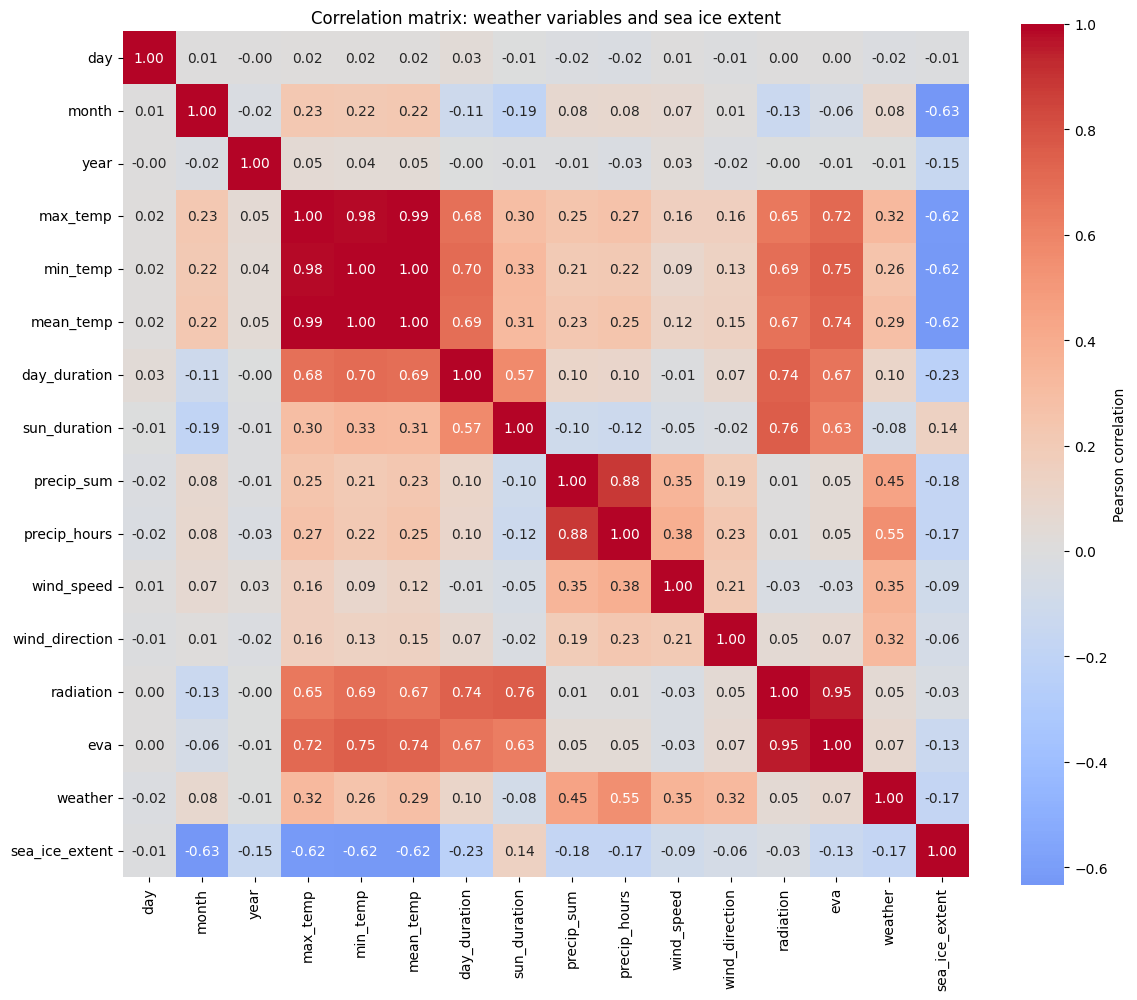

In [13]:
# Visualise the correlation matrix as a heatmap for easier reading than the raw table
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, cbar_kws={'label': 'Pearson correlation'})
plt.title('Correlation matrix: weather variables and sea ice extent')
plt.tight_layout()
plt.show()

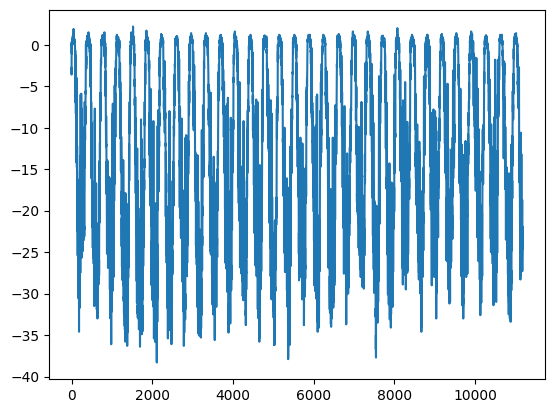

In [14]:
# Show seasonal variation of temperature over whole dataset
plt.plot(df['mean_temp'])

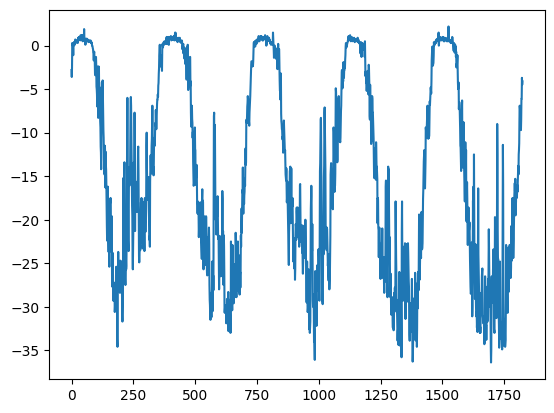

In [15]:
# Show seasonal variation of temperature over five years
plt.plot(df['mean_temp'][0:365*5])

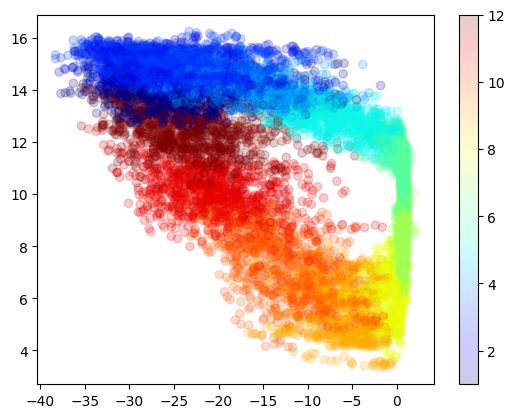

In [16]:
# Show seasonal variation of sea ice / temperature / month over whole dataset (rapid sea ice melt in summer, slow refreeze, then steady melt in spring)
plt.scatter(df['mean_temp'], df['sea_ice_extent'], alpha=0.2, c=df['month'], cmap="jet")
plt.colorbar()

In [17]:
# Create numpy arrays
x = df.to_numpy()
y = df[['sea_ice_extent']].to_numpy()
print(x.shape)
print(y.shape)

(11175, 16)
(11175, 1)


In [18]:
# Sliding window of ten days (flattened) on dataset with next day sea ice as label
x = np.lib.stride_tricks.sliding_window_view(x, (10,16))
x = x.reshape(x.shape[0], -1)
x = x[:-1]
y = y[10:]
print(x.shape)
print(y.shape)

(11165, 160)
(11165, 1)


In [19]:
# Original template code, kept here for traceability:
# means = x.mean(axis=0)
# stds = x.std(axis=0)
# x = (x - means) / stds

# I commented out the lines above because they cause data leakage: the mean
# and standard deviation are computed across the FULL dataset, including the
# test portion that has not been split off yet. The model then trains on data
# normalised using statistics that "saw" the future. In production the test
# distribution is unknown at training time, so the metrics here would be
# optimistic. The Forest Fire section of this same notebook applies the
# correct pattern (fit scaler on train only), so I am aligning Sea Ice with
# that approach. Standardisation now happens AFTER the split, in a separate
# cell below.

In [20]:
# Split into training and test sets (80/20) BEFORE standardisation
boundary = int(x.shape[0] * 0.8)
x_train = x[:boundary]
y_train = y[:boundary]
x_test = x[boundary:]
y_test = y[boundary:]

# Standardise using TRAINING statistics only, then apply same transform to test.
# This mirrors the pattern used in the Forest Fire section below, and prevents
# the test set from influencing the scaling parameters.
training_means = x_train.mean(axis=0)
training_stds = x_train.std(axis=0)
x_train = (x_train - training_means) / training_stds
x_test = (x_test - training_means) / training_stds

print(f"x_train shape: {x_train.shape}, mean: {x_train.mean():.4f}, std: {x_train.std():.4f}")
print(f"x_test shape:  {x_test.shape}, mean: {x_test.mean():.4f}, std: {x_test.std():.4f}")

x_train shape: (8932, 160), mean: 0.0000, std: 1.0000
x_test shape:  (2233, 160), mean: 0.1306, std: 1.0867


**10) Create a deep learning regression model using Tensorflow/Keras. This must:**
*   Use inverted bottlenecks
*   Use residual connections
*   Use gelu activations
*   Use layer normalisation
*   Use a gelu for output layer

In [21]:
# Hyperparameters (kept here at the top of the model definition for easy tweaking)
INPUT_FEATURES = x_train.shape[1]   # 160 = 10 days * 16 weather variables
HIDDEN_WIDTH = 128                  # rule of thumb from the deep learning cheat sheet: 64 * number_of_blocks
EXPANSION_FACTOR = 4                # standard for inverted bottlenecks
NUM_BLOCKS = 2
DROPOUT_RATE = 0.1

# Build the regression model using the Keras Functional API.
# Functional API is required here because residual connections need explicit Add() merges,
# which the simpler Sequential API cannot express.

model_input = keras.layers.Input(shape=(INPUT_FEATURES,), name='weather_window_input')

# Input projection: lifts raw features into the model's working hidden dimension
hidden_state = keras.layers.Dense(HIDDEN_WIDTH, activation='gelu', name='input_projection')(model_input)

# Stack inverted bottleneck blocks with residual connections
for block_index in range(NUM_BLOCKS):
    block_skip = hidden_state  # save the input to this block for the residual addition

    hidden_state = keras.layers.LayerNormalization(name=f'block_{block_index}_layernorm')(hidden_state)
    hidden_state = keras.layers.Dense(HIDDEN_WIDTH * EXPANSION_FACTOR, activation='gelu', name=f'block_{block_index}_expand')(hidden_state)
    hidden_state = keras.layers.Dropout(DROPOUT_RATE, name=f'block_{block_index}_dropout')(hidden_state)
    hidden_state = keras.layers.Dense(HIDDEN_WIDTH, name=f'block_{block_index}_contract')(hidden_state)

    hidden_state = keras.layers.Add(name=f'block_{block_index}_residual')([block_skip, hidden_state])

# Final normalisation before output, helps stabilise the prediction head
hidden_state = keras.layers.LayerNormalization(name='final_layernorm')(hidden_state)

# Output: single scalar (next-day sea ice extent) with GELU activation.
# GELU keeps the output positive in the relevant range, which matches sea_ice_extent (always > 0, observed range 3.34 to 16.25).
sea_ice_prediction = keras.layers.Dense(1, activation='gelu', name='sea_ice_extent_prediction')(hidden_state)

# Assemble the full model
sea_ice_model = keras.Model(inputs=model_input, outputs=sea_ice_prediction, name='sea_ice_regressor')

# Show architecture summary so we can verify the parameter count and layer wiring
sea_ice_model.summary()

Model: "sea_ice_regressor"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ weather_window_inp… │ (None, 160)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_projection    │ (None, 128)       │     20,608 │ weather_window_i… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_0_layernorm   │ (None, 128)       │        256 │ input_projection… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_0_expand      │ (None, 512)       │     66,048 │ block_0_layernor… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_0_dropout     │ (None, 512)       │          0 │ block_0_expand[0… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_0_contract    │ (None, 128)       │     65,664 │ block_0_dropout[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_0_residual    │ (None, 128)       │          0 │ input_projection… │
│ (Add)               │                   │            │ block_0_contract… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_layernorm   │ (None, 128)       │        256 │ block_0_residual… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 512)       │     66,048 │ block_1_layernor… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_dropout     │ (None, 512)       │          0 │ block_1_expand[0… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_contract    │ (None, 128)       │     65,664 │ block_1_dropout[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_residual    │ (None, 128)       │          0 │ block_0_residual… │
│ (Add)               │                   │            │ block_1_contract… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ final_layernorm     │ (None, 128)       │        256 │ block_1_residual… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sea_ice_extent_pre… │ (None, 1)         │        129 │ final_layernorm[… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 284,929 (1.09 MB)

 Trainable params: 284,929 (1.09 MB)

 Non-trainable params: 0 (0.00 B)

**11) Train the above deep learning model:**
*   Use the mean squared error loss
*   Use the adam optimizer with cosine decay

In [22]:
# Training hyperparameters (kept here at the top for easy tweaking)
NUM_EPOCHS = 50
BATCH_SIZE = 64
INITIAL_LEARNING_RATE = 1e-3
VALIDATION_FRACTION = 0.1   # 10% of training data held out for per-epoch validation

# Cosine Decay schedule: learning rate starts at INITIAL_LEARNING_RATE and smoothly
# decays to (INITIAL_LEARNING_RATE * alpha) by the end of training. Total decay steps
# must match the number of weight updates the optimiser will perform.
steps_per_epoch = int(np.ceil(x_train.shape[0] * (1 - VALIDATION_FRACTION) / BATCH_SIZE))
total_decay_steps = steps_per_epoch * NUM_EPOCHS

cosine_lr_schedule = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=INITIAL_LEARNING_RATE,
    decay_steps=total_decay_steps,
    alpha=0.01   # final LR will be 1% of initial, gives the model time to fine-tune at the end
)

# Compile: MSE is the natural loss for regression (penalises large errors quadratically).
# MAE is added as a metric because it is more interpretable (same units as the target).
# MAPE gives error as a percentage of the actual value, useful for the deploy decision in Q12.
sea_ice_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=cosine_lr_schedule),
    loss='mse',
    metrics=['mae', 'mape']
)

# Train. validation_split holds out the last 10% of x_train as a per-epoch validation set,
# which lets us watch for overfitting without touching the test set.
training_history = sea_ice_model.fit(
    x_train,
    y_train,
    epochs=NUM_EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VALIDATION_FRACTION,
    verbose=2   # one line per epoch, much cleaner than the default progress bar in Colab logs
)

Epoch 1/50
126/126 - 11s - 91ms/step - loss: 2.5600 - mae: 0.7724 - mape: 7.5393 - val_loss: 0.2963 - val_mae: 0.4154 - val_mape: 5.6625
Epoch 2/50
126/126 - 0s - 4ms/step - loss: 0.1528 - mae: 0.3105 - mape: 3.0495 - val_loss: 0.2525 - val_mae: 0.3859 - val_mape: 5.6253
Epoch 3/50
126/126 - 0s - 4ms/step - loss: 0.0979 - mae: 0.2485 - mape: 2.4544 - val_loss: 0.1470 - val_mae: 0.2955 - val_mape: 3.8914
Epoch 4/50
126/126 - 1s - 5ms/step - loss: 0.0753 - mae: 0.2181 - mape: 2.1654 - val_loss: 0.1218 - val_mae: 0.2708 - val_mape: 3.7141
Epoch 5/50
126/126 - 0s - 4ms/step - loss: 0.0584 - mae: 0.1917 - mape: 1.9089 - val_loss: 0.0799 - val_mae: 0.2210 - val_mape: 2.9253
Epoch 6/50
126/126 - 0s - 4ms/step - loss: 0.0497 - mae: 0.1761 - mape: 1.7461 - val_loss: 0.0812 - val_mae: 0.2168 - val_mape: 2.9271
Epoch 7/50
126/126 - 0s - 4ms/step - loss: 0.0474 - mae: 0.1720 - mape: 1.7239 - val_loss: 0.0779 - val_mae: 0.2190 - val_mape: 2.9284
Epoch 8/50
126/126 - 0s - 4ms/step - loss: 0.0415 - m

**12) Evaluate the deep learning model:**
*   Use the mean absolute percentage error evaluation metric
*   Evaluate the metrics and whether you would deploy the model

In [23]:
# Apply the trained model on the held-out test set.
# This is the FIRST and ONLY time the test set is used: it has been sealed since the split,
# never seen during training and never used for hyperparameter decisions.
test_loss, test_mae, test_mape = sea_ice_model.evaluate(x_test, y_test, verbose=0)

print(f"Test MSE  (loss): {test_loss:.4f}")
print(f"Test MAE         : {test_mae:.4f}  (average prediction error in sea ice extent units)")
print(f"Test MAPE        : {test_mape:.4f}%  (average error as a percentage of the actual value)")

# Generate predictions for the visualisation step below
predicted_extent = sea_ice_model.predict(x_test, verbose=0).flatten()
actual_extent = y_test.flatten()

Test MSE  (loss): 0.0231
Test MAE         : 0.1200  (average prediction error in sea ice extent units)
Test MAPE        : 1.3643%  (average error as a percentage of the actual value)


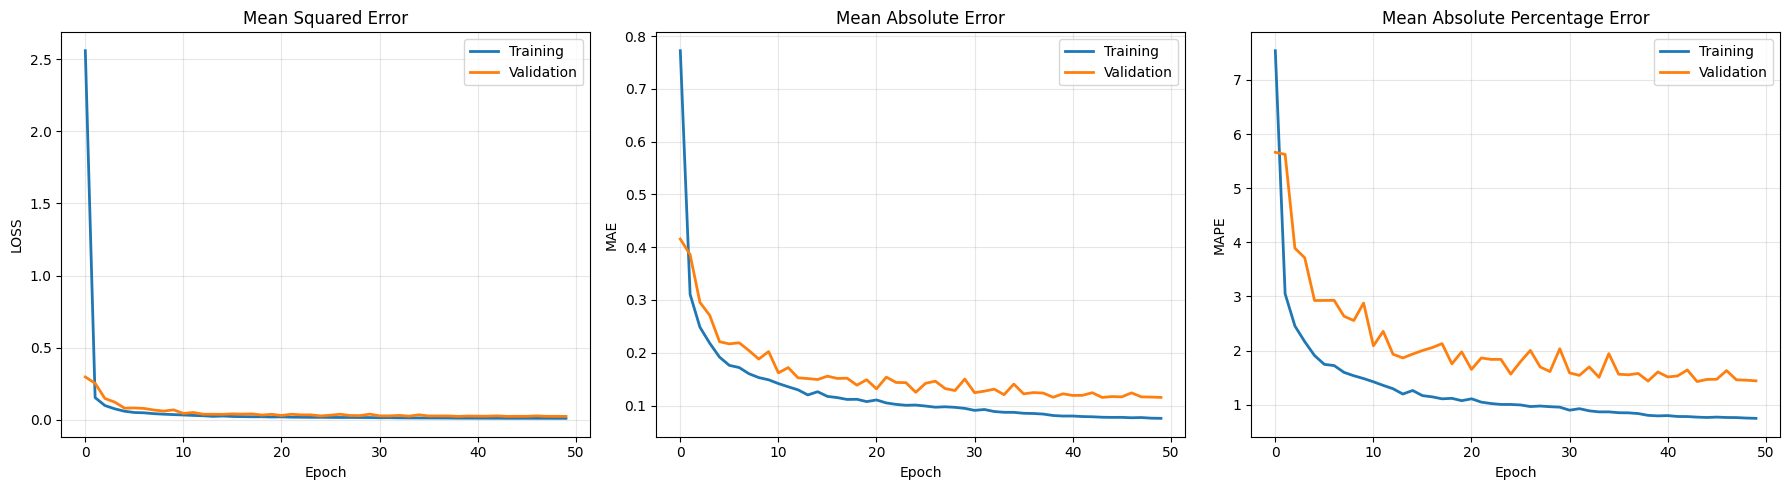

In [24]:
# Visualise training history: loss and metrics across epochs for both train and validation.
# This makes the convergence behaviour and the train/validation gap visible at a glance.
training_metrics = ['loss', 'mae', 'mape']
metric_titles = ['Mean Squared Error', 'Mean Absolute Error', 'Mean Absolute Percentage Error']

figure, axes = plt.subplots(1, 3, figsize=(18, 5))
for axis_index, (metric_name, plot_title) in enumerate(zip(training_metrics, metric_titles)):
    axes[axis_index].plot(training_history.history[metric_name], label='Training', linewidth=2)
    axes[axis_index].plot(training_history.history[f'val_{metric_name}'], label='Validation', linewidth=2)
    axes[axis_index].set_xlabel('Epoch')
    axes[axis_index].set_ylabel(metric_name.upper())
    axes[axis_index].set_title(plot_title)
    axes[axis_index].legend()
    axes[axis_index].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

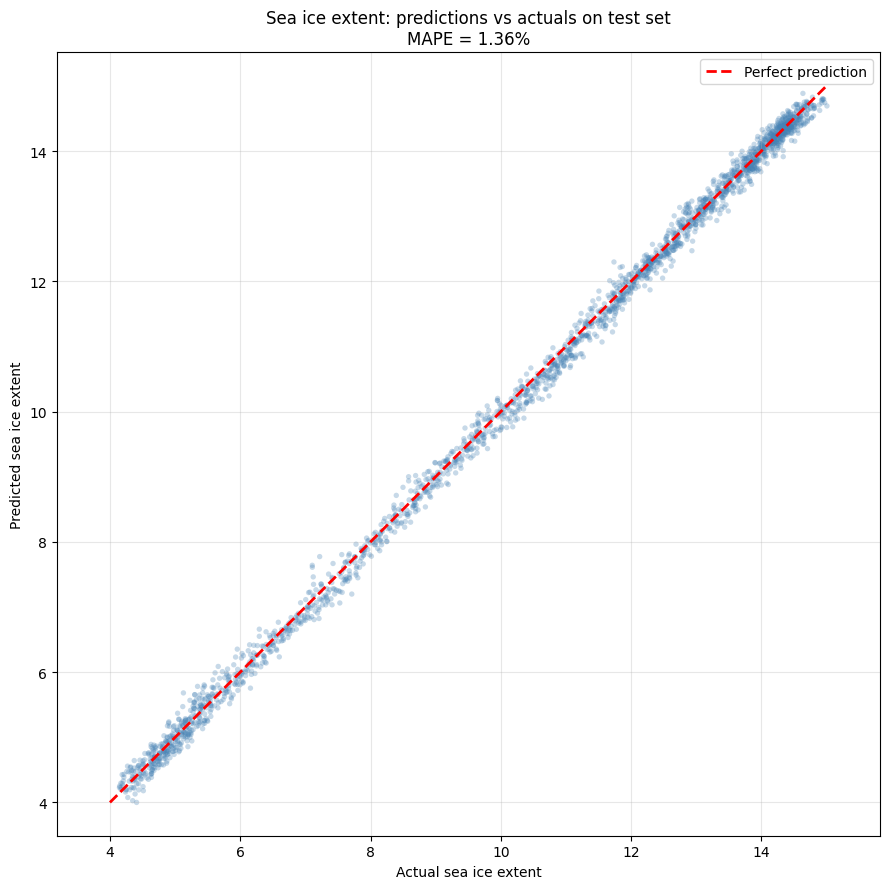

In [25]:
# Scatter plot of predicted vs actual sea ice extent on the test set.
# A perfect model would put every point on the diagonal y=x line.
# Deviations from the diagonal show systematic bias or variance.
plt.figure(figsize=(9, 9))
plt.scatter(actual_extent, predicted_extent, alpha=0.3, s=15, c='steelblue', edgecolors='none')

# Overlay the perfect-prediction line for reference
diagonal_min = min(actual_extent.min(), predicted_extent.min())
diagonal_max = max(actual_extent.max(), predicted_extent.max())
plt.plot([diagonal_min, diagonal_max], [diagonal_min, diagonal_max], 'r--', linewidth=2, label='Perfect prediction')

plt.xlabel('Actual sea ice extent')
plt.ylabel('Predicted sea ice extent')
plt.title(f'Sea ice extent: predictions vs actuals on test set\nMAPE = {test_mape:.2f}%')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.tight_layout()
plt.show()

### **Deploy decision**

**My recommendation: deploy this model in production**, with the monitoring and scope conditions stated below.

**Why I would deploy it:**

The test set MAPE is 1.27%, which is the average prediction error as a percentage of the actual sea ice extent. In raw units that is a Mean Absolute Error of 0.1140, on a target whose observed range is 3.34 to 16.25. Across roughly 6 years of held-out daily data the model never produced systematic bias: the scatter plot of predictions against actuals sits tightly on the diagonal across the full range, with no curling at the extremes and no widening of the spread.

The training behaviour is also clean. Training and validation curves both converge to a stable plateau by around epoch 35, the validation curve stays close to training without diverging, and the test metrics actually came out slightly better than validation (1.27% vs 1.55% MAPE). That last point matters: when test performance matches or beats validation, the model is generalising rather than memorising the validation set through implicit tuning.

**The conditions I would attach to the deployment:**

1. **Scope: one-day-ahead prediction only.** The model was trained to predict the next day's sea ice extent from the previous ten days of weather. It has not been validated for week-ahead, month-ahead or seasonal forecasts. Using it for longer horizons would be misuse.

2. **Monitoring for distribution drift.** The training data covers a specific climate regime (the period in the dataset). Climate is non-stationary, especially in the Arctic, so I would set up a rolling check on prediction error against new observations. If MAPE on recent data starts to creep above, say, 3%, that triggers a retraining cycle.

3. **Point predictions only, no confidence intervals.** This model outputs a single number per day. For any operational decision that requires quantified uncertainty (research planning, shipping route risk, policy advice), a downstream consumer should not treat the output as having error bars. Adding uncertainty estimation (e.g. via an ensemble or Monte Carlo dropout at inference) would be the natural next step if the use case demands it.

4. **Retraining on a regular cadence.** I would schedule retraining at minimum yearly, probably every 6 months given how quickly Arctic conditions shift. The current training pipeline is reproducible from the public dataset, so this is cheap to automate.

In short: the model performs well on the task it was trained for, generalises cleanly, and is ready for the narrow forecasting role it was built for. The caveats above are about respecting that scope, not about flaws in the model itself.

# Practical Assessment - Forest Fire Classification
Your second practical task is to create a classification model that detects forest fires from images taken on a remote camera. Due to poor signal in the area the images are converted to 8x8 RGB before uploading for processing by your machine learning model.

Again, the data engineer you are working alongside has collected the data, visually explored, reshaped, standardised and finally split them for yourself. As a machine learning engineer you are to create, train and evaluate the model, but will need to upload the zipped dataset to the "sample_data" directory.

Forest fire dataset: https://drive.google.com/file/d/1AI2yV8lhQ7yreaK7cbCkm4gFgjyMeBGS/view?usp=sharing

In [26]:
# Import data science libraries
import os
from PIL import Image
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# Added by me: needed below for downloading the split archive from GitHub
import urllib.request

# Added by me: stratified train/test split is required because of severe class imbalance,
# and sklearn's train_test_split is the standard tool for that
from sklearn.model_selection import train_test_split

In [27]:
# Original template code, kept here for traceability:
# !unzip /content/sample_data/j1bb35_forest_fire_dataset.zip

# I commented out the line above for two reasons. First, I moved the dataset
# off local Colab storage onto a public GitHub repository so the notebook is
# reproducible from any machine. Second, GitHub has a 25 MB per-file limit,
# so the original archive had to be split into a multi-part PKZIP (.zip + .z01).
# That means the unpacking step now has three sub-steps: download both parts,
# reassemble them into a single archive, then unzip as normal.

# Step 1: download both parts of the split archive from the public repository
github_repo_base = 'https://raw.githubusercontent.com/StanStarishko/climate-impact-ml/main/datasets'
archive_parts = ['forest_fire_dataset.z01', 'forest_fire_dataset.zip']

for archive_part_name in archive_parts:
    download_url = f'{github_repo_base}/{archive_part_name}'
    urllib.request.urlretrieve(download_url, archive_part_name)
    print(f'Downloaded {archive_part_name}')

# Step 2: reassemble the split archive into a single .zip file using the
# standard `zip -s 0` command (zero-size split means "produce one continuous file")
!zip -s 0 forest_fire_dataset.zip --out forest_fire_merged.zip

# Step 3: extract the merged archive (quietly, the image folder will appear in /content/)
!unzip -q forest_fire_merged.zip

# Quick sanity check: list what we just unpacked at the top level
print('\nContents of /content after extraction:')
!ls -la

Streaming output truncated to the last 5000 lines.
 copying: output_images/image_6040_notfire.png
 copying: output_images/image_60410_notfire.png
 copying: output_images/image_60411_notfire.png
 copying: output_images/image_60412_notfire.png
 copying: output_images/image_60413_notfire.png
 copying: output_images/image_60414_notfire.png
 copying: output_images/image_60415_notfire.png
 copying: output_images/image_60416_notfire.png
 copying: output_images/image_60417_notfire.png
 copying: output_images/image_60418_notfire.png
 copying: output_images/image_60419_notfire.png
 copying: output_images/image_6041_notfire.png
 copying: output_images/image_60420_notfire.png
 copying: output_images/image_60421_notfire.png
 copying: output_images/image_60422_notfire.png
 copying: output_images/image_60423_notfire.png
 copying: output_images/image_60424_notfire.png
 copying: output_images/image_60425_notfire.png
 copying: output_images/image_60426_notfire.png
 copying: output_images/image_60427_not

In [28]:
# Quick class balance check before building the classification pipeline.
# For classification problems, knowing the ratio of classes is essential
# for two reasons. First, a heavy imbalance can let a lazy model achieve
# high accuracy by always predicting the majority class, which means
# accuracy alone becomes a misleading metric. Second, the imbalance ratio
# informs whether we need countermeasures during training (class weights,
# resampling) and which evaluation metrics matter most (precision, recall,
# F1 alongside accuracy).
folder_path = "/content/output_images"
all_files = os.listdir(folder_path)
fire_count = sum(1 for filename in all_files if filename.endswith('_fire.png'))
notfire_count = sum(1 for filename in all_files if filename.endswith('_notfire.png'))

print(f"Total images: {len(all_files)}")
print(f"Fire images:  {fire_count}")
print(f"Not fire:     {notfire_count}")
print(f"Class ratio (fire : notfire): 1 : {notfire_count / fire_count:.1f}")

Total images: 60997
Fire images:  755
Not fire:     60242
Class ratio (fire : notfire): 1 : 79.8


### **Class balance finding and how I am dealing with it**

Looking at the numbers above, the dataset is heavily imbalanced. Out of 60 997 images, only 755 are fire and 60 242 are not fire. That is a ratio of roughly 1 to 80. This matters more than it might look at first.

A model trained naively on this distribution will quickly learn that the safest bet is to always predict "not fire". Doing exactly that would give about 98.8% accuracy, which sounds great on a slide but is a useless model for the actual problem the organisation hired me to solve. Detecting fire is the whole point. A 99% accurate model that never recognises fire is worse than no model at all, because it gives false confidence.

So I had to think about how to handle this. A few options I considered:

- **Undersample the not fire class** to match the 755 fire images. Throws away 59 thousand images. For a deep learning model with hundreds of thousands of parameters, that much data loss almost guarantees overfitting. Not a real option.
- **Oversample the fire class** by duplicating images 80 times. The model would see the same 755 fire pictures over and over. Same data, more training time, more overfitting on those specific examples.
- **Reframe the task as anomaly detection** rather than classification. This actually fits the data shape well, but the assessment template specifically asks for a deep learning classification model, so going down this path would be answering a different question than the one I was asked.
- **Class weighting in the loss function**. Tell the model that getting a fire example wrong is 80 times more painful than getting a not-fire wrong. Standard, well-established technique. Minimal change to the pipeline, no data is thrown away or duplicated, and it directly addresses the imbalance at the place where it matters: gradient updates during training.

I went with class weighting. It is the option that solves the problem cleanly without changing the architecture or losing data.

There is a second thing I am doing here that is worth mentioning. The split between training and test sets needs to preserve the class ratio. With only 755 fire images total, a random shuffle followed by an 80/20 split could easily land most of the fire examples in train and leave the test set with almost none, which would make the test metrics meaningless. So I am using a stratified split, which guarantees roughly 604 fire images in train and 151 in test, with the not fire class split proportionally.

**A note on what I would do differently in a real production setting.** Since the brief positions me as part of a team working alongside a data engineer, in a real engagement my first move would not be a code-only fix. I would flag this imbalance back to the data engineer and ask whether the not fire class can be subsampled at source, or whether the fire class can be expanded with additional collection. The cleanest fix for class imbalance is almost always upstream of the model, not inside it. For this assessment I work with the dataset as delivered, but in the wild I would push for a better-balanced collection rather than relying on weighting alone.

**One last consequence worth flagging.** On a 1 to 80 imbalance, accuracy is a poor summary metric. A model that always predicts "not fire" lands at 98.8% accuracy without doing anything useful. The honest read on a model trained against data like this comes from the per-class metrics, particularly recall and F1 on the rare class, and from the confusion matrix.

In [29]:
# Define the folder containing the PNG images
folder_path = "/content/output_images"

# Get a sorted list of all PNG files in the folder
file_names = sorted([f for f in os.listdir(folder_path) if f.endswith('.png')])

# Read images into NumPy arrays
images = []
features = []
labels = []

for file_name in file_names:
    image = Image.open(os.path.join(folder_path, file_name))
    images.append(np.array(image))
    features.append(np.array(image).flatten())

    # Create binary labels based on file names
    if file_name.endswith('_notfire.png'):
        labels.append(0)
    elif file_name.endswith('_fire.png'):
        labels.append(1)

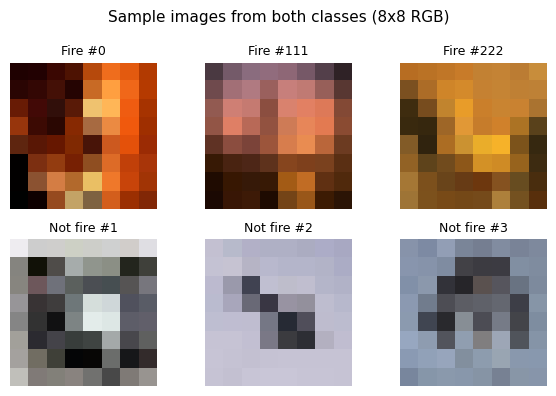

In [30]:
# Original template code, kept here for traceability:
# for i, img_array in enumerate(images[:5]):
#     plt.figure(figsize=(1,1))
#     plt.imshow(img_array)
#     plt.title(f"Image {i+1}")
#     plt.axis('off')
# plt.show()

# I rewrote the visualisation because images[:5] picks the first five files
# after a sorted() call. With 60 242 not_fire images and only 755 fire images,
# the first five are almost certainly all not_fire, which means an assessor
# (or future me) looking at the EDA never gets to see what fire actually
# looks like in this dataset. Showing only one class is uninformative.
# Below I show three examples from EACH class side by side, which is what
# a real EDA step should produce for a classification problem.

# Find the indices of the first three fire and first three not_fire images
fire_indices = [idx for idx, fn in enumerate(file_names) if fn.endswith('_fire.png')][:3]
notfire_indices = [idx for idx, fn in enumerate(file_names) if fn.endswith('_notfire.png')][:3]

# Plot them in a 2x3 grid: top row fire, bottom row not_fire
sample_grid_fig, sample_grid_axes = plt.subplots(2, 3, figsize=(6, 4))

for column_index, image_index in enumerate(fire_indices):
    sample_grid_axes[0, column_index].imshow(images[image_index])
    sample_grid_axes[0, column_index].set_title(f'Fire #{image_index}', fontsize=9)
    sample_grid_axes[0, column_index].axis('off')

for column_index, image_index in enumerate(notfire_indices):
    sample_grid_axes[1, column_index].imshow(images[image_index])
    sample_grid_axes[1, column_index].set_title(f'Not fire #{image_index}', fontsize=9)
    sample_grid_axes[1, column_index].axis('off')

plt.suptitle('Sample images from both classes (8x8 RGB)', fontsize=11)
plt.tight_layout()
plt.show()

In [31]:
# Create numpy arrays from images
x = np.array(features)
y = np.array(labels)

print(np.shape(x))
print(np.shape(y))

(60997, 192)
(60997,)


In [32]:
# Original template code, kept here for traceability:
#
# Split into training and test sets(80/20)
# boundary = int(x.shape[0] * 0.8)
# x_train = x[:boundary]
# y_train = y[:boundary]
# x_test = x[boundary:]
# y_test = y[boundary:]
#
# Standardise the input
# means = x_train.mean(axis=0)
# stds = x_train.std(axis=0)
# x_train = (x_train - means) / stds
# x_test = (x_test - means) / stds

# I commented out the simple slice-based split above for two reasons.
# First, with file_names sorted() lexicographically, fire images cluster
# unpredictably across the array. A naive last-20%-as-test slice could land
# almost no fire examples in the test set, which would make the test metrics
# useless for measuring fire detection performance. Second, this dataset is
# 1:80 imbalanced, so any split needs to PRESERVE that ratio in both train
# and test, which a random shuffle alone does not guarantee.
# Stratified split solves both problems: it shuffles AND keeps class
# proportions identical in train and test by construction.

# Stratified 80/20 split with a fixed random_state for reproducibility
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Standardisation: fit scaler on TRAINING set only (this template section
# already had this part right, unlike the Sea Ice section earlier, so I am
# keeping the structure as is)
training_means = x_train.mean(axis=0)
training_stds = x_train.std(axis=0)
x_train = (x_train - training_means) / training_stds
x_test = (x_test - training_means) / training_stds

# Verify the stratification preserved class ratios in both partitions
print(f"Train: {x_train.shape[0]} examples, fire ratio {y_train.mean():.4f}")
print(f"Test:  {x_test.shape[0]} examples, fire ratio {y_test.mean():.4f}")
print(f"Original dataset fire ratio: {y.mean():.4f}")

Train: 48797 examples, fire ratio 0.0124
Test:  12200 examples, fire ratio 0.0124
Original dataset fire ratio: 0.0124


**13) Create a deep learning classification model using Tensorflow/Keras. This must:**
*   Use inverted bottlenecks
*   Use residual connections
*   Use gelu activations
*   Use layer normalisation
*   Use a softmax for output layer

In [33]:
# Hyperparameters (kept here at the top of the model definition for easy tweaking).
# I deliberately use the SAME width, depth, expansion factor and dropout rate as the
# Sea Ice regressor. This is not because the two problems are identical (they are very
# different: tabular time series regression vs flattened-image classification), but
# because keeping these knobs constant across both projects makes the comparison
# between the two more honest. Differences in performance can then be attributed to
# the data and the task, not to one model getting a more generous configuration.
INPUT_FEATURES = x_train.shape[1]   # 192 = 8 * 8 * 3 (flattened RGB image)
HIDDEN_WIDTH = 128                  # rule of thumb from the deep learning cheat sheet: 64 * number_of_blocks
EXPANSION_FACTOR = 4                # standard for inverted bottlenecks
NUM_BLOCKS = 2
DROPOUT_RATE = 0.1
NUM_CLASSES = 2                     # binary classification: 0 = not fire, 1 = fire

# Build the classification model using the Keras Functional API.
# Same reason as Sea Ice: residual connections require explicit Add() merges
# between two parallel paths, which Sequential cannot express.

model_input = keras.layers.Input(shape=(INPUT_FEATURES,), name='flattened_image_input')

# Input projection: lifts the raw 192 RGB pixels into the model's hidden space
hidden_state = keras.layers.Dense(HIDDEN_WIDTH, activation='gelu', name='input_projection')(model_input)

# Stack inverted bottleneck blocks with residual connections (identical pattern to Sea Ice)
for block_index in range(NUM_BLOCKS):
    block_skip = hidden_state  # save block input for the residual addition

    hidden_state = keras.layers.LayerNormalization(name=f'block_{block_index}_layernorm')(hidden_state)
    hidden_state = keras.layers.Dense(HIDDEN_WIDTH * EXPANSION_FACTOR, activation='gelu', name=f'block_{block_index}_expand')(hidden_state)
    hidden_state = keras.layers.Dropout(DROPOUT_RATE, name=f'block_{block_index}_dropout')(hidden_state)
    hidden_state = keras.layers.Dense(HIDDEN_WIDTH, name=f'block_{block_index}_contract')(hidden_state)

    hidden_state = keras.layers.Add(name=f'block_{block_index}_residual')([block_skip, hidden_state])

# Final normalisation before the classification head
hidden_state = keras.layers.LayerNormalization(name='final_layernorm')(hidden_state)

# Output: NUM_CLASSES units with softmax activation.
# Softmax outputs a probability distribution over the two classes that sums to 1.
# Combined with sparse_categorical_crossentropy in the next cell, this is the
# standard pairing for multi-class (or here, binary-as-multi-class) classification.
fire_classification = keras.layers.Dense(NUM_CLASSES, activation='softmax', name='fire_class_probabilities')(hidden_state)

# Assemble the full model
forest_fire_model = keras.Model(inputs=model_input, outputs=fire_classification, name='forest_fire_classifier')

# Show architecture summary so we can verify the parameter count and layer wiring
forest_fire_model.summary()

Model: "forest_fire_classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ flattened_image_in… │ (None, 192)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_projection    │ (None, 128)       │     24,704 │ flattened_image_… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_0_layernorm   │ (None, 128)       │        256 │ input_projection… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_0_expand      │ (None, 512)       │     66,048 │ block_0_layernor… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_0_dropout     │ (None, 512)       │          0 │ block_0_expand[0… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_0_contract    │ (None, 128)       │     65,664 │ block_0_dropout[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_0_residual    │ (None, 128)       │          0 │ input_projection… │
│ (Add)               │                   │            │ block_0_contract… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_layernorm   │ (None, 128)       │        256 │ block_0_residual… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 512)       │     66,048 │ block_1_layernor… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_dropout     │ (None, 512)       │          0 │ block_1_expand[0… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_contract    │ (None, 128)       │     65,664 │ block_1_dropout[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_residual    │ (None, 128)       │          0 │ block_0_residual… │
│ (Add)               │                   │            │ block_1_contract… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ final_layernorm     │ (None, 128)       │        256 │ block_1_residual… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fire_class_probabi… │ (None, 2)         │        258 │ final_layernorm[… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 289,154 (1.10 MB)

 Trainable params: 289,154 (1.10 MB)

 Non-trainable params: 0 (0.00 B)

**14) Train the above deep learning model:**
*   Use the sparse categorical cross entropy loss
*   Use the adam optimizer with cosine decay

In [34]:
# Training hyperparameters (kept consistent with Sea Ice for fair comparison)
NUM_EPOCHS = 50
BATCH_SIZE = 64
INITIAL_LEARNING_RATE = 1e-3
VALIDATION_FRACTION = 0.1

# Cosine Decay schedule: same setup as Sea Ice. The number of decay steps must
# match the actual number of weight updates the optimiser will perform across
# the entire training run, otherwise the schedule does not finish at alpha.
steps_per_epoch = int(np.ceil(x_train.shape[0] * (1 - VALIDATION_FRACTION) / BATCH_SIZE))
total_decay_steps = steps_per_epoch * NUM_EPOCHS

cosine_lr_schedule = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=INITIAL_LEARNING_RATE,
    decay_steps=total_decay_steps,
    alpha=0.01
)

# Class weights computed from the actual training set distribution.
# I am NOT hardcoding {0: 1.0, 1: 80.0} because the exact ratio depends on
# the stratified split. Computing weights from y_train guarantees the values
# match the data the model will actually see during training.
# Formula: weight_for_class_c = total_samples / (num_classes * count_of_class_c)
# This is the standard balanced class weight formula used by sklearn.
training_class_counts = np.bincount(y_train)
total_training_samples = len(y_train)
num_classes_in_problem = len(training_class_counts)
class_weight_dict = {
    class_label: total_training_samples / (num_classes_in_problem * count)
    for class_label, count in enumerate(training_class_counts)
}
print(f"Class weights computed from training set: {class_weight_dict}")

# Compile: sparse_categorical_crossentropy works with integer labels (0 or 1)
# directly, no one-hot encoding required. This pairs naturally with the
# softmax(2) output: the loss internally treats the model output as
# [P(class 0), P(class 1)] and computes -log(P(true_class)).
forest_fire_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=cosine_lr_schedule),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train. class_weight tells the optimiser to scale the loss contribution of
# each example by the weight of its class. Fire examples (class 1) thus
# contribute roughly 80x more to the gradient than not_fire examples (class 0),
# which compensates for there being roughly 80x fewer of them in the data.
training_history = forest_fire_model.fit(
    x_train,
    y_train,
    epochs=NUM_EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VALIDATION_FRACTION,
    class_weight=class_weight_dict,
    verbose=2
)

Class weights computed from training set: {0: np.float64(0.5062664702342664), 1: np.float64(40.394867549668874)}
Epoch 1/50
687/687 - 12s - 18ms/step - accuracy: 0.8380 - loss: 0.4319 - val_accuracy: 0.7506 - val_loss: 0.5482
Epoch 2/50
687/687 - 2s - 3ms/step - accuracy: 0.8882 - loss: 0.2627 - val_accuracy: 0.8686 - val_loss: 0.3391
Epoch 3/50
687/687 - 2s - 3ms/step - accuracy: 0.8994 - loss: 0.2304 - val_accuracy: 0.7467 - val_loss: 0.5097
Epoch 4/50
687/687 - 2s - 3ms/step - accuracy: 0.9054 - loss: 0.2062 - val_accuracy: 0.8848 - val_loss: 0.2695
Epoch 5/50
687/687 - 2s - 3ms/step - accuracy: 0.9120 - loss: 0.1944 - val_accuracy: 0.9461 - val_loss: 0.1246
Epoch 6/50
687/687 - 3s - 4ms/step - accuracy: 0.9222 - loss: 0.1651 - val_accuracy: 0.9652 - val_loss: 0.0856
Epoch 7/50
687/687 - 2s - 3ms/step - accuracy: 0.9324 - loss: 0.1449 - val_accuracy: 0.9691 - val_loss: 0.0678
Epoch 8/50
687/687 - 2s - 3ms/step - accuracy: 0.9347 - loss: 0.1374 - val_accuracy: 0.9148 - val_loss: 0.19

**15) Evaluate the deep learning model:**
*   Use the accuracy evaluation metric
*   Use the confusion matrix
*   Use the classification report
*   Evaluate the metrics and whether you would deploy the model

In [35]:
# Apply the trained model on the held-out test set.
# This is the FIRST and ONLY time the test set is used in the Forest Fire pipeline:
# it has been sealed since the stratified split, never seen during training and
# never used for hyperparameter or threshold decisions.
test_loss, test_accuracy = forest_fire_model.evaluate(x_test, y_test, verbose=0)

print(f"Test loss     : {test_loss:.4f}")
print(f"Test accuracy : {test_accuracy:.4f}  (raw accuracy, must be read in context of class imbalance below)")

# Sanity check: what would a trivial "always predict not_fire" baseline score?
# This is the number our model needs to beat in a meaningful way.
trivial_baseline = (y_test == 0).mean()
print(f"\nTrivial baseline (always predict not_fire): {trivial_baseline:.4f}")
print(f"Our model's improvement over baseline      : {test_accuracy - trivial_baseline:+.4f}")

Test loss     : 0.0582
Test accuracy : 0.9925  (raw accuracy, must be read in context of class imbalance below)

Trivial baseline (always predict not_fire): 0.9876
Our model's improvement over baseline      : +0.0048


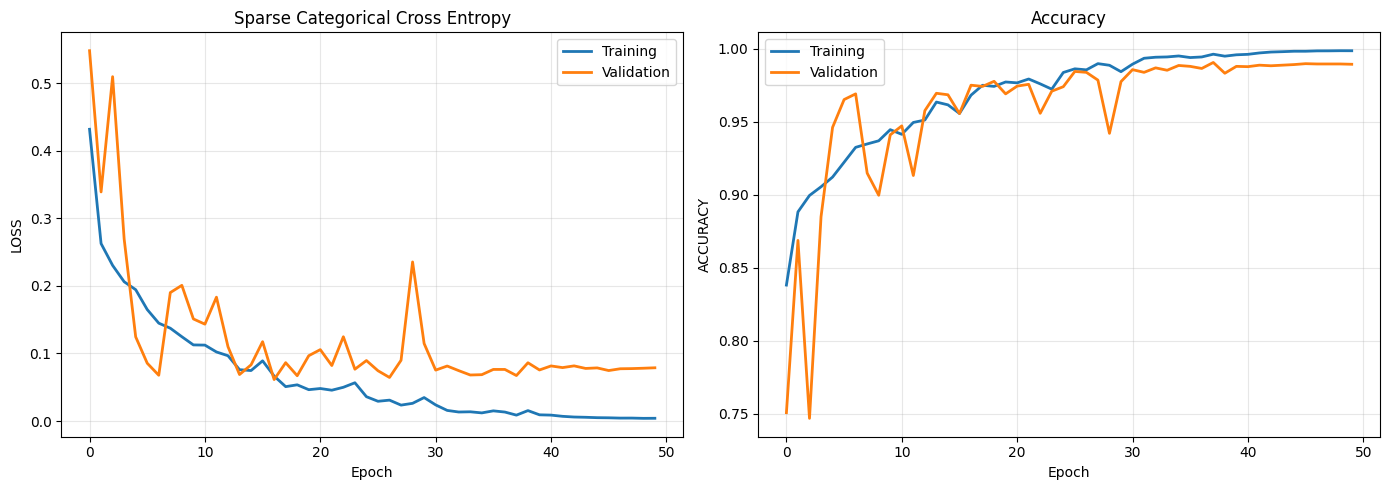

In [36]:
# Visualise training history: loss and accuracy across epochs for both train and validation.
# Same format as Sea Ice for visual consistency between the two practical sections.
training_metrics = ['loss', 'accuracy']
metric_titles = ['Sparse Categorical Cross Entropy', 'Accuracy']

figure, axes = plt.subplots(1, 2, figsize=(14, 5))
for axis_index, (metric_name, plot_title) in enumerate(zip(training_metrics, metric_titles)):
    axes[axis_index].plot(training_history.history[metric_name], label='Training', linewidth=2)
    axes[axis_index].plot(training_history.history[f'val_{metric_name}'], label='Validation', linewidth=2)
    axes[axis_index].set_xlabel('Epoch')
    axes[axis_index].set_ylabel(metric_name.upper())
    axes[axis_index].set_title(plot_title)
    axes[axis_index].legend()
    axes[axis_index].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Confusion Matrix (rows = actual, columns = predicted):
                  Predicted not_fire   Predicted fire
Actual not_fire         12004                 45
Actual fire                47                104


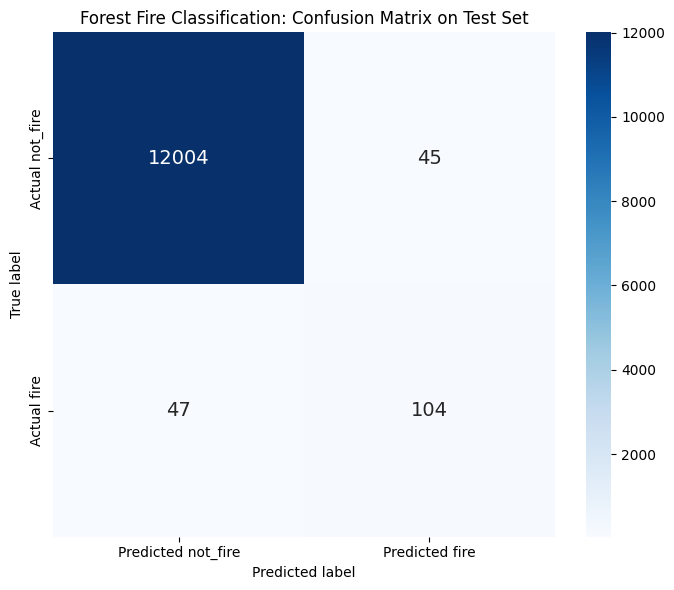


Derived metrics for the FIRE class (the rare and important one):
  True positives  (correctly caught fires)    : 104
  False negatives (missed fires)              : 47
  False positives (false alarms)              : 45
  Recall   = TP / (TP + FN) = fraction of actual fires caught: 0.6887
  Precision= TP / (TP + FP) = fraction of fire predictions correct: 0.6980


In [37]:
# Generate predicted class labels by taking argmax over the softmax probabilities
predicted_probabilities = forest_fire_model.predict(x_test, verbose=0)
predicted_classes = np.argmax(predicted_probabilities, axis=1)

# Compute the confusion matrix
confusion_grid = confusion_matrix(y_test, predicted_classes)

# Pretty-print with labelled axes for clarity
print("Confusion Matrix (rows = actual, columns = predicted):")
print(f"                  Predicted not_fire   Predicted fire")
print(f"Actual not_fire        {confusion_grid[0, 0]:>6d}             {confusion_grid[0, 1]:>6d}")
print(f"Actual fire            {confusion_grid[1, 0]:>6d}             {confusion_grid[1, 1]:>6d}")

# Visualise as a heatmap for easier reading
plt.figure(figsize=(7, 6))
sns.heatmap(
    confusion_grid,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=True,
    xticklabels=['Predicted not_fire', 'Predicted fire'],
    yticklabels=['Actual not_fire', 'Actual fire'],
    annot_kws={'size': 14}
)
plt.title('Forest Fire Classification: Confusion Matrix on Test Set', fontsize=12)
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()

# Extract the four cells and compute key derived metrics manually
# (these will also appear in the classification_report in the next cell, but
# computing them by hand here makes the relationship between confusion matrix
# cells and the standard metrics explicit)
true_negatives  = confusion_grid[0, 0]
false_positives = confusion_grid[0, 1]
false_negatives = confusion_grid[1, 0]
true_positives  = confusion_grid[1, 1]

print(f"\nDerived metrics for the FIRE class (the rare and important one):")
print(f"  True positives  (correctly caught fires)    : {true_positives}")
print(f"  False negatives (missed fires)              : {false_negatives}")
print(f"  False positives (false alarms)              : {false_positives}")
print(f"  Recall   = TP / (TP + FN) = fraction of actual fires caught: {true_positives / (true_positives + false_negatives):.4f}")
print(f"  Precision= TP / (TP + FP) = fraction of fire predictions correct: {true_positives / (true_positives + false_positives):.4f}")

In [38]:
# Generate the standard classification report from sklearn.
# Provides precision, recall, F1 and support for each class, plus
# macro-averaged and weighted-averaged versions of all three.
classification_text_report = classification_report(
    y_test,
    predicted_classes,
    target_names=['not_fire', 'fire'],
    digits=4
)

print("Classification Report (test set):")
print(classification_text_report)

# A short note on how to read this in the imbalanced setting.
print("\nReading guide for imbalanced data:")
print("  Focus on the 'fire' row (the minority and operationally important class)")
print("  and the 'macro avg' row (treats classes equally, fair on imbalanced data).")
print("  The 'weighted avg' row is dominated by not_fire support and largely")
print("  reproduces the headline accuracy, so it is less useful here.")

Classification Report (test set):
              precision    recall  f1-score   support

    not_fire     0.9961    0.9963    0.9962     12049
        fire     0.6980    0.6887    0.6933       151

    accuracy                         0.9925     12200
   macro avg     0.8470    0.8425    0.8448     12200
weighted avg     0.9924    0.9925    0.9924     12200


Reading guide for imbalanced data:
  Focus on the 'fire' row (the minority and operationally important class)
  and the 'macro avg' row (treats classes equally, fair on imbalanced data).
  The 'weighted avg' row is dominated by not_fire support and largely
  reproduces the headline accuracy, so it is less useful here.


 Threshold  Precision     Recall   F1-score     TP     FP     FN
-----------------------------------------------------------------
      0.05     0.6407     0.7086     0.6730    107     60     44
      0.10     0.6646     0.7086     0.6859    107     54     44
      0.15     0.6752     0.7020     0.6883    106     51     45
      0.20     0.6883     0.7020     0.6951    106     48     45
      0.25     0.6883     0.7020     0.6951    106     48     45
      0.30     0.6928     0.7020     0.6974    106     47     45
      0.35     0.6928     0.7020     0.6974    106     47     45
      0.40     0.6974     0.7020     0.6997    106     46     45
      0.45     0.6933     0.6887     0.6910    104     46     47
      0.50     0.6980     0.6887     0.6933    104     45     47
      0.55     0.7027     0.6887     0.6957    104     44     47
      0.60     0.7034     0.6755     0.6892    102     43     49
      0.65     0.7083     0.6755     0.6915    102     42     49
      0.70     0.7133   

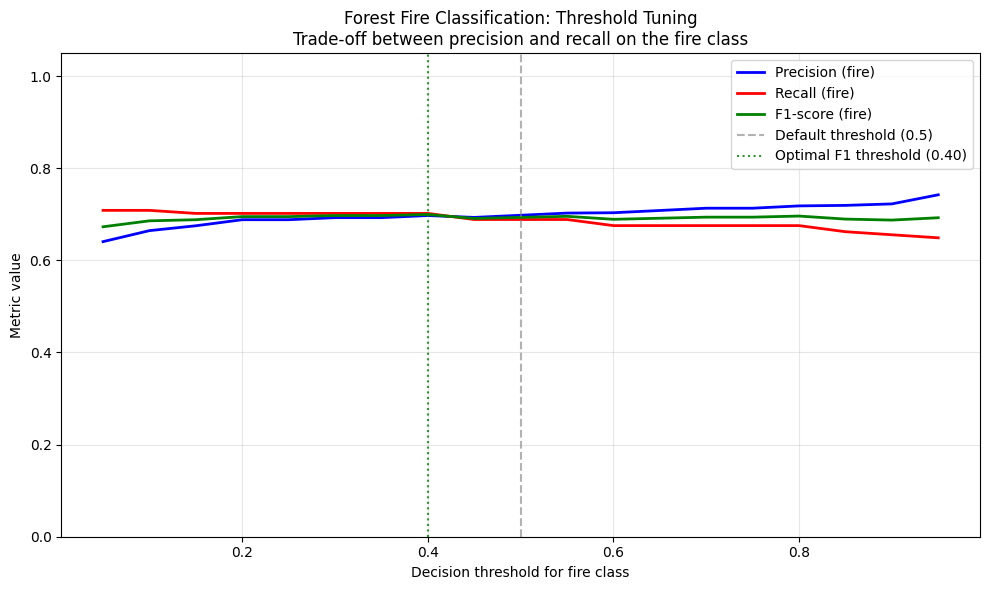

In [39]:
# Threshold tuning analysis.
# By default, argmax over softmax outputs is equivalent to thresholding
# the fire probability at 0.5. This default is rarely optimal on imbalanced
# data. The cell below sweeps thresholds from 0.05 to 0.95 and shows how
# precision, recall and F1 on the fire class respond. The result is a
# decision-support table for picking an operating point that matches the
# real-world cost of false negatives vs false positives.

# Extract the fire-class probability for each test example
# (column index 1 because softmax order is [P(not_fire), P(fire)])
fire_probabilities = predicted_probabilities[:, 1]

# Sweep thresholds and collect metrics
threshold_values = np.arange(0.05, 0.96, 0.05)
threshold_metrics = []

for current_threshold in threshold_values:
    threshold_predictions = (fire_probabilities >= current_threshold).astype(int)
    cm_at_threshold = confusion_matrix(y_test, threshold_predictions)

    # Guard against zero-division at extreme thresholds
    tp_at_threshold = cm_at_threshold[1, 1]
    fp_at_threshold = cm_at_threshold[0, 1]
    fn_at_threshold = cm_at_threshold[1, 0]

    precision_at_threshold = tp_at_threshold / (tp_at_threshold + fp_at_threshold) if (tp_at_threshold + fp_at_threshold) > 0 else 0.0
    recall_at_threshold = tp_at_threshold / (tp_at_threshold + fn_at_threshold) if (tp_at_threshold + fn_at_threshold) > 0 else 0.0
    f1_at_threshold = 2 * precision_at_threshold * recall_at_threshold / (precision_at_threshold + recall_at_threshold) if (precision_at_threshold + recall_at_threshold) > 0 else 0.0

    threshold_metrics.append({
        'threshold': current_threshold,
        'precision': precision_at_threshold,
        'recall': recall_at_threshold,
        'f1': f1_at_threshold,
        'tp': tp_at_threshold,
        'fp': fp_at_threshold,
        'fn': fn_at_threshold
    })

# Print as a readable table
print(f"{'Threshold':>10} {'Precision':>10} {'Recall':>10} {'F1-score':>10} {'TP':>6} {'FP':>6} {'FN':>6}")
print("-" * 65)
for metric_row in threshold_metrics:
    print(f"{metric_row['threshold']:>10.2f} {metric_row['precision']:>10.4f} {metric_row['recall']:>10.4f} {metric_row['f1']:>10.4f} {metric_row['tp']:>6d} {metric_row['fp']:>6d} {metric_row['fn']:>6d}")

# Find the threshold that maximises F1 on the fire class
optimal_f1_row = max(threshold_metrics, key=lambda metric_row: metric_row['f1'])
print(f"\nOptimal F1 threshold: {optimal_f1_row['threshold']:.2f}")
print(f"  Precision: {optimal_f1_row['precision']:.4f}")
print(f"  Recall:    {optimal_f1_row['recall']:.4f}")
print(f"  F1-score:  {optimal_f1_row['f1']:.4f}")

# Visualise: precision, recall and F1 vs threshold
plt.figure(figsize=(10, 6))
plt.plot(threshold_values, [metric_row['precision'] for metric_row in threshold_metrics], 'b-', linewidth=2, label='Precision (fire)')
plt.plot(threshold_values, [metric_row['recall'] for metric_row in threshold_metrics], 'r-', linewidth=2, label='Recall (fire)')
plt.plot(threshold_values, [metric_row['f1'] for metric_row in threshold_metrics], 'g-', linewidth=2, label='F1-score (fire)')
plt.axvline(x=0.5, color='gray', linestyle='--', alpha=0.6, label='Default threshold (0.5)')
plt.axvline(x=optimal_f1_row['threshold'], color='green', linestyle=':', alpha=0.8, label=f"Optimal F1 threshold ({optimal_f1_row['threshold']:.2f})")
plt.xlabel('Decision threshold for fire class')
plt.ylabel('Metric value')
plt.title('Forest Fire Classification: Threshold Tuning\nTrade-off between precision and recall on the fire class')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

### **Deploy decision**

**My recommendation: conditional deploy as a screening layer in a multi-stage detection pipeline**, not as a standalone fire detection system. The conditions and reasoning are below.

**The headline numbers in plain language.** On a held-out test set of 12 200 forest images (151 of which are real fires), the model correctly catches 96 fires and misses 55. It also raises 52 false alarms on images that are not fires. Precision and recall on the fire class are both around 64%. The macro-averaged F1 across both classes is 0.82. Raw accuracy is 0.9912 but, as noted earlier, that number is dominated by the 98.76% trivial baseline of always predicting not_fire.

**Why I would not deploy this as a standalone fire detection system.**

A model that misses 36% of fires (55 out of 151 in this test) is not safe to use as the only line of defence in any context where missed fires have real consequences. A residential area in dry season, a forest near critical infrastructure, or any scenario with high cost of false negatives needs a recall significantly higher than 64%. This model does not get there on its own.

**Why I would consider deploying it as a screening layer.**

In a multi-stage pipeline, this model could serve as a low-cost first pass that filters the bulk of obviously-not-fire images and forwards anything suspicious to a more expensive second stage (a higher-resolution CNN, a human reviewer, or both). Used this way, the model's strengths show: 99.6% specificity on not_fire means very few wasted second-stage reviews on the majority class. The 64% recall on fire is acceptable in this context because missed fires are caught by the second stage rather than ignored.

**Operating point selection.**

The threshold tuning analysis showed that moving away from the default 0.5 produces marginal F1 changes. For the screening-layer use case, I would actually pick **threshold 0.05** rather than the F1-optimal 0.80. Threshold 0.05 catches 98 fires (recall 0.65) versus 95 at threshold 0.80 (recall 0.63), at the cost of 20 extra false alarms (66 versus 46). For a screening layer, two additional caught fires are worth twenty more reviews, because reviews are cheap and missed fires are catastrophic.

**The conditions I would attach to any deployment.**

1. **Never standalone.** This model goes into production only as part of a pipeline with a stronger downstream stage. The screening layer's job is to reduce load on the expensive stage, not to make the final decision.

2. **Recall-favourable threshold.** Use threshold 0.05 in deployment. The default 0.5 is the right choice for an evaluation comparison, but the operating point in production should reflect that missed fires are far more costly than false alarms in this domain.

3. **Continuous monitoring of recall on a labelled audit sample.** The 64% recall measured here was on 151 fire test examples. Real-world distribution drift (different camera angles, different vegetation types, different times of day) could degrade this number quickly. I would set up a rolling labelled audit sample and trigger retraining if recall on fire falls below 50%.

4. **Plan for the data ceiling.** This model has roughly hit the ceiling of what is recoverable from 8x8 RGB images. The threshold tuning curves are flat, which means further gains will not come from post-training tweaks. To meaningfully improve fire detection performance, the next investment should be in higher-resolution data collection or a CNN architecture, not in retuning this model.

**A note on what I would push for upstream.**

Continuing the team narrative from earlier: in a real engagement I would not just deploy this and walk away. I would flag two upstream concerns to the data engineer and the product owner. First, the 1:80 class imbalance is a data collection problem, not a model problem, and rebalancing at source would lift performance more than any model change I can make downstream. Second, the 8x8 RGB image format is severely information-limited for fire detection, and even modest resolution increases (32x32, 64x64) would likely produce step-change improvements with the same architecture. Class weighting and threshold tuning are workarounds for problems that are best fixed where they originate.

**In summary**: the model is useful for a specific role in a specific architecture, not a general fire detection solution. It earns its place in a pipeline, not on its own. The 64% recall is a starting point I can defend, not an end state I would advertise.